#Setup

In [18]:
import os
import requests
import time
import math
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

#Download Shakespeare Data

In [19]:
cache_dir = "./tmp"
os.makedirs(cache_dir, exist_ok=True)

dataset_file_name = "shakespeare.txt"
dataset_file_origin = "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"

file_path = os.path.join(cache_dir, dataset_file_name)

if not os.path.exists(file_path):
    print("Downloading dataset ...")
    data = requests.get(dataset_file_origin).text
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(data)
    print("Download complete.")
else:
    print("Dataset already exists.")

Dataset already exists.


#Load the Text & Build Vocabulary

###Analyze the dataset

In [20]:
with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

print("Text characters length:", len(text))

Text characters length: 1115394


In [21]:
# Take a look at the first 300 characters in text.
print(text[:300])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


###Character vocabulary

In [22]:
# The unique characters in the text
chars = sorted(list(set(text)))
vocab_size = len(chars)

print("Unique chars:", vocab_size)
print(chars)

Unique chars: 65
['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


###Vectorize the text

In [23]:
# Map characters to their indices in vocabulary.
char2idx = {char: index for index, char in enumerate(chars)}

print('{')
for char, _ in zip(char2idx, range(20)):
    print('  {:4s}: {:3d},'.format(repr(char), char2idx[char]))
print('  ...\n}')



{
  '\n':   0,
  ' ' :   1,
  '!' :   2,
  '$' :   3,
  '&' :   4,
  "'" :   5,
  ',' :   6,
  '-' :   7,
  '.' :   8,
  '3' :   9,
  ':' :  10,
  ';' :  11,
  '?' :  12,
  'A' :  13,
  'B' :  14,
  'C' :  15,
  'D' :  16,
  'E' :  17,
  'F' :  18,
  'G' :  19,
  ...
}


In [24]:
# Map character indices to characters from vacabulary.
idx2char = {index:char for char,index in char2idx.items()}
print(idx2char)

{0: '\n', 1: ' ', 2: '!', 3: '$', 4: '&', 5: "'", 6: ',', 7: '-', 8: '.', 9: '3', 10: ':', 11: ';', 12: '?', 13: 'A', 14: 'B', 15: 'C', 16: 'D', 17: 'E', 18: 'F', 19: 'G', 20: 'H', 21: 'I', 22: 'J', 23: 'K', 24: 'L', 25: 'M', 26: 'N', 27: 'O', 28: 'P', 29: 'Q', 30: 'R', 31: 'S', 32: 'T', 33: 'U', 34: 'V', 35: 'W', 36: 'X', 37: 'Y', 38: 'Z', 39: 'a', 40: 'b', 41: 'c', 42: 'd', 43: 'e', 44: 'f', 45: 'g', 46: 'h', 47: 'i', 48: 'j', 49: 'k', 50: 'l', 51: 'm', 52: 'n', 53: 'o', 54: 'p', 55: 'q', 56: 'r', 57: 's', 58: 't', 59: 'u', 60: 'v', 61: 'w', 62: 'x', 63: 'y', 64: 'z'}


###Encode the Full Text

In [25]:
# Convert chars in text to indices.
encoded = torch.tensor([char2idx[char] for char in text], dtype=torch.long)

print("Encoded shape:", encoded.shape)


Encoded shape: torch.Size([1115394])


In [26]:
# Show a few samples before & after encoding
num_examples = 200   # number of characters to preview

original_sample = text[:num_examples]
encoded_sample = encoded[:num_examples]

print("\nOriginal characters:")
print(repr(original_sample))

print("\nEncoded indices:")
print(encoded_sample.tolist())


Original characters:
'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you'

Encoded indices:
[18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56, 43, 1, 61, 43, 1, 54, 56, 53, 41, 43, 43, 42, 1, 39, 52, 63, 1, 44, 59, 56, 58, 46, 43, 56, 6, 1, 46, 43, 39, 56, 1, 51, 43, 1, 57, 54, 43, 39, 49, 8, 0, 0, 13, 50, 50, 10, 0, 31, 54, 43, 39, 49, 6, 1, 57, 54, 43, 39, 49, 8, 0, 0, 18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 37, 53, 59, 1, 39, 56, 43, 1, 39, 50, 50, 1, 56, 43, 57, 53, 50, 60, 43, 42, 1, 56, 39, 58, 46, 43, 56, 1, 58, 53, 1, 42, 47, 43, 1, 58, 46, 39, 52, 1, 58, 53, 1, 44, 39, 51, 47, 57, 46, 12, 0, 0, 13, 50, 50, 10, 0, 30, 43, 57, 53, 50, 60, 43, 42, 8, 1, 56, 43, 57, 53, 50, 60, 43, 42, 8, 0, 0, 18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 18, 47, 56, 57, 58, 6, 

In [27]:
# The maximum length sentence we want for a single input in characters.
sequence_length =100
batch_size = 64

examples_per_epoch = len(text) // (sequence_length + 1)

print('examples_per_epoch:', examples_per_epoch)

examples_per_epoch: 11043


#Create Dataset

###Dataset class

In [28]:
class CharDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y

###DataLoader

In [29]:
dataset = CharDataset(encoded, sequence_length)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

In [30]:
# For each sequence, duplicate and shift it to form the input and target text
xb, yb = next(iter(data_loader))
print("Batch input shape:", xb.shape)
print("Batch target shape:", yb.shape)

Batch input shape: torch.Size([64, 100])
Batch target shape: torch.Size([64, 100])


In [31]:
# Decode a few sequences to inspect them
num_examples_to_show = 3

for i in range(num_examples_to_show):
    inp = ''.join(idx2char[idx.item()] for idx in xb[i])
    tgt = ''.join(idx2char[idx.item()] for idx in yb[i])

    print(f"\nExample {i+1}:")
    print("Input sequence:")
    print(repr(inp[:120]))   # print first 120 chars only

    print("\nTarget sequence:")
    print(repr(tgt[:120]))


Example 1:
Input sequence:
"ceremony that to great ones 'longs,\nNot the king's crown, nor the deputed sword,\nThe marshal's trunc"

Target sequence:
"eremony that to great ones 'longs,\nNot the king's crown, nor the deputed sword,\nThe marshal's trunch"

Example 2:
Input sequence:
'nger:\nMy gracious sovereign, now in Devonshire,\nAs I by friends am well advertised,\nSir Edward Court'

Target sequence:
'ger:\nMy gracious sovereign, now in Devonshire,\nAs I by friends am well advertised,\nSir Edward Courtn'

Example 3:
Input sequence:
"nd my young rover, he's\nApparent to my heart.\n\nHERMIONE:\nIf you would seek us,\nWe are yours i' the g"

Target sequence:
"d my young rover, he's\nApparent to my heart.\n\nHERMIONE:\nIf you would seek us,\nWe are yours i' the ga"


#Define a Simple RNN Model

In [32]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256):
        super().__init__()
        self.hidden_dim = hidden_dim   # ← store it!
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embed(x)
        out, hidden = self.rnn(x, hidden)
        logits = self.fc(out)
        return logits, hidden

    def init_hidden(self, batch):
        return torch.zeros(1, batch, self.hidden_dim).to(device)


#Training Setup for RNN

In [33]:
model = RNNModel(vocab_size).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

#Training With Early Stopping

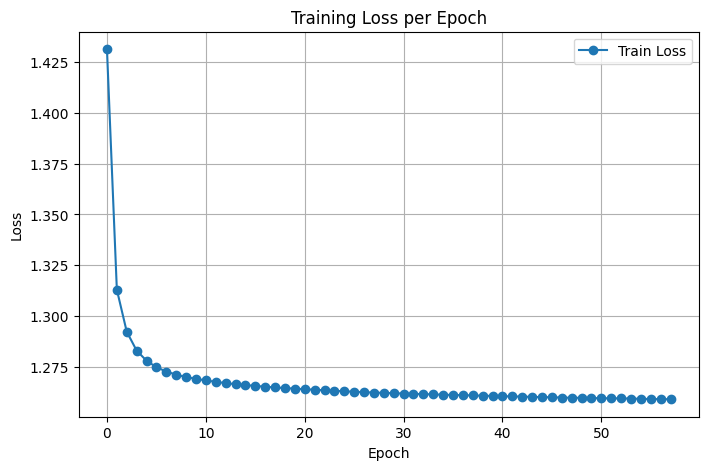

In [38]:
# train_losses = []

# best_train_loss = float('inf')
# patience = 4
# wait = 0

# num_epochs = 100

# for epoch in range(1, num_epochs + 1):
#     model.train()
#     total_loss = 0
#     steps = 0

#     # TRAIN LOOP
#     for x, y in data_loader:
#         x = x.to(device)
#         y = y.to(device)

#         hidden = model.init_hidden(x.size(0))

#         optimizer.zero_grad()
#         logits, hidden = model(x, hidden)

#         loss = loss_fn(
#             logits.reshape(-1, vocab_size),
#             y.reshape(-1)
#         )

#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()
#         steps += 1

#     # TRAIN LOSS
#     train_loss = total_loss / steps
#     train_losses.append(train_loss)

#     print(f"Epoch {epoch}/{num_epochs}")
#     print(f"  Train Loss: {train_loss:.4f}")

#     # EARLY STOPPING
#     if train_loss <= best_train_loss:
#         best_train_loss = train_loss
#         wait = 0
#         torch.save(model.state_dict(), "best_model.pth")
#     else:
#         wait += 1
#         print(f" -> No improvement. Patience: {wait}/{patience}")
#         if wait >= patience:
#             print("Training-loss early stopping triggered!")
#             break


checkpoint_path = "/content/drive/MyDrive/KP_MODEL/shakespeare_rnn.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
train_losses = checkpoint["train_losses"]


# PLOT TRAINING LOSS
plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o', label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss per Epoch")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#Text Generation

In [ ]:
def sample_logits(logits, temperature=1.0):
    logits = logits / temperature
    probs = torch.softmax(logits, dim=-1)
    return torch.multinomial(probs, 1).item()

def generate(model, start="ROMEO:", length=500, temperature=0.8):
    model.eval()

    input_ids = torch.tensor([[char2idx[c] for c in start]], dtype=torch.long).to(device)
    hidden = model.init_hidden(1)

    generated = list(start)

    with torch.no_grad():
        for _ in range(length):
            logits, hidden = model(input_ids, hidden)
            last_logits = logits[0, -1]
            next_id = sample_logits(last_logits, temperature)
            generated.append(idx2char[next_id])

            input_ids = torch.tensor([[next_id]], dtype=torch.long).to(device)

    return "".join(generated)



###Generate Sample With RNN


In [ ]:
print(generate(model, start="ROMEO:\n", length=600, temperature=0.7))


# LSTM

In [ ]:
class LSTMTextGen(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512, num_layers=2, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embed = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        x = self.embed(x)
        out, hidden = self.lstm(x, hidden)
        logits = self.fc(out)
        return logits, hidden

    def init_hidden(self, batch):
        h = torch.zeros(self.num_layers, batch, self.hidden_dim).to(device)
        c = torch.zeros(self.num_layers, batch, self.hidden_dim).to(device)
        return (h, c)


###LSTM Training Setup

In [ ]:
# NEW LSTM MODEL + OPTIMIZER
lstm_model = LSTMTextGen(vocab_size).to(device)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
lstm_loss_fn = nn.CrossEntropyLoss()

# SEPARATE STORAGE LISTS
lstm_train_losses = []


###LSTM Early Stopping Training Loop

In [ ]:
best_lstm_train_loss = float('inf')
lstm_patience = 4
lstm_wait = 0

lstm_epochs = 100

for epoch in range(1, lstm_epochs + 1):
    lstm_model.train()
    total_loss = 0
    steps = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        hidden = lstm_model.init_hidden(x.size(0))

        lstm_optimizer.zero_grad()
        logits, hidden = lstm_model(x, hidden)

        loss = lstm_loss_fn(
            logits.reshape(-1, vocab_size),
            y.reshape(-1)
        )

        loss.backward()
        lstm_optimizer.step()

        total_loss += loss.item()
        steps += 1

    # TRAIN LOSS
    train_loss = total_loss / steps
    lstm_train_losses.append(train_loss)

    print(f"[LSTM] Epoch {epoch}/{lstm_epochs}")
    print(f"   LSTM Train Loss: {train_loss:.4f}")

    # EARLY STOPPING BASED ON TRAINING LOSS
    if train_loss <= best_lstm_train_loss:
        best_lstm_train_loss = train_loss
        lstm_wait = 0
        torch.save(lstm_model.state_dict(), "best_LSTM_model.pth")

    else:
        lstm_wait += 1
        print(f"   → No improvement. Patience: {lstm_wait}/{lstm_patience}")

        if lstm_wait >= lstm_patience:
            print("LSTM Early stopping triggered (based on training loss)!")
            break


In [ ]:
plt.figure(figsize=(8,5))
plt.plot(lstm_train_losses, marker='o', label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss per Epoch")
plt.grid(True)
plt.legend()
plt.show()

####Generate Sample With LSTM


In [ ]:
lstm_model.load_state_dict(torch.load("best_LSTM_model.pth"))
print(generate(lstm_model, start="ROMEO:\n", length=500, temperature=0.7))


#Save model

In [35]:
# from google.colab import drive
# drive.mount('/content/drive')

# save_dir = "/content/drive/MyDrive/KP_MODEL"
# os.makedirs(save_dir, exist_ok=True)

# print("Saving directory:", save_dir)

Mounted at /content/drive
Saving directory: /content/drive/MyDrive/KP_MODEL


In [36]:
# model_path = os.path.join(save_dir, "shakespeare_rnn.pth")

# torch.save({
#     "model_state_dict": model.state_dict(),
#     "vocab_size": vocab_size,
#     "char2idx": char2idx,
#     "idx2char": idx2char,
#     "sequence_length": sequence_length,
#     "train_losses":train_losses,
# }, model_path)

# print("Model saved to:", model_path)

Model saved to: /content/drive/MyDrive/KP_MODEL/shakespeare_rnn.pth
